# Retail Sales & Financial Performance Analytics

## Project Overview

This project analyzes retail sales data to understand sales performance, profitability, customer behavior, product performance, regional trends, discount impact, and business growth.

### Objective

The objective is to identify key business trends, profitability drivers, high-performing products and customers, and areas where business performance can be improved.

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

### Dataset

Superstore Retail Sales Dataset

## 1. Data Loading & Initial Inspection

The Superstore dataset is loaded into a Pandas DataFrame for analysis.

This section includes:
- Loading the dataset
- Reviewing the first few records
- Checking dataset dimensions
- Reviewing column names and data types

In [1]:
# Import required libraries for data analysis and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the Superstore dataset
# The CSV uses Windows-1252 encoding

df = pd.read_csv("Superstore.csv", encoding="cp1252")

# Display the first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Check dataset structure

print("Rows and Columns:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Rows and Columns: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


## 2. Data Quality Check

Before performing the analysis, the dataset was checked for data quality issues.

The following checks were performed:

- Duplicate rows
- Missing values
- Data types
- Date format
- Overall dataset completeness

In [5]:
# Check dataset information and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
# Generate statistical summary for numerical columns

df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
# Check for duplicate rows

duplicate_rows = df.duplicated().sum()
print("Total duplicate rows:",duplicate_rows)

Total duplicate rows: 0


In [8]:
# check for missing Values

missing_values = df.isnull().sum()
print(missing_values)

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [14]:
# Convert date columns to datetime format

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Check the data types

print(df['Order Date'].dtypes)
print(df['Ship Date'].dtypes)

datetime64[ns]
datetime64[ns]


## 3. Basic Business KPIs

This section calculates the key business performance indicators of the retail dataset.

The main KPIs include:

- Total Sales
- Total Profit
- Total Orders
- Total Customers

In [15]:
# Calculate Basic Business KPIs

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()

print("total Sales:",round(total_sales,2))
print("Total Profit:",round(total_profit,2))
print("Total Orders:",total_orders)
print("Total Customers:",total_customers)



total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Total Customers: 793


## 4. Category-wise Sales & Profit Analysis

This analysis evaluates sales and profitability across different product categories.

The analysis includes:

- Total Sales by Category
- Total Profit by Category
- Profit Margin by Category
- Comparison of category-level performance

In [17]:
# Analyze sales and profit by category

category_analysis = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

category_analysis['Profit_Margin_%'] = (
    category_analysis['Total_Profit']
    / category_analysis['Total_Sales']
) * 100

category_analysis = category_analysis.sort_values(
    'Total_Sales',
    ascending = False
)

category_analysis

,Category,Total_Sales,Total_Profit,Profit_Margin_%
2,Technology,836154.0330,145454.9481,17.395712
0,Furniture,741999.7953,18451.2728,2.486695
1,Office Supplies,719047.0320,122490.8008,17.035158


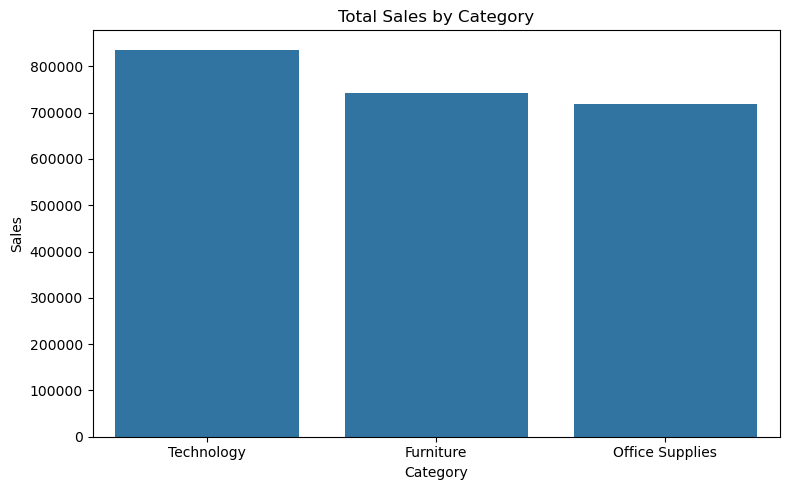

In [18]:
# Visualize sales by category

plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_analysis,
    x='Category',
    y='Total_Sales'
)

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Region-wise Sales & Profit Analysis

This analysis compares sales and profitability across different geographic regions.

The analysis includes:

- Total Sales by Region
- Total Profit by Region
- Profit Margin by Region
- Regional performance comparison

In [19]:
# Analyze sales and profit by region

region_analysis = df.groupby('Region').agg(
    Total_Sales = ('Sales', 'sum'),
    Total_Profit = ('Profit', 'sum')
).reset_index()

region_analysis['Profit_Margin_%'] = (
    region_analysis['Total_Profit']
    / region_analysis['Total_Sales']
) * 100

region_analysis = region_analysis.sort_values(
    'Total_Sales',
    ascending=False
)

region_analysis

,Region,Total_Sales,Total_Profit,Profit_Margin_%
3,West,725457.8245,108418.4489,14.944831
1,East,678781.2400,91522.7800,13.483399
0,Central,501239.8908,39706.3625,7.921629
2,South,391721.9050,46749.4303,11.934342


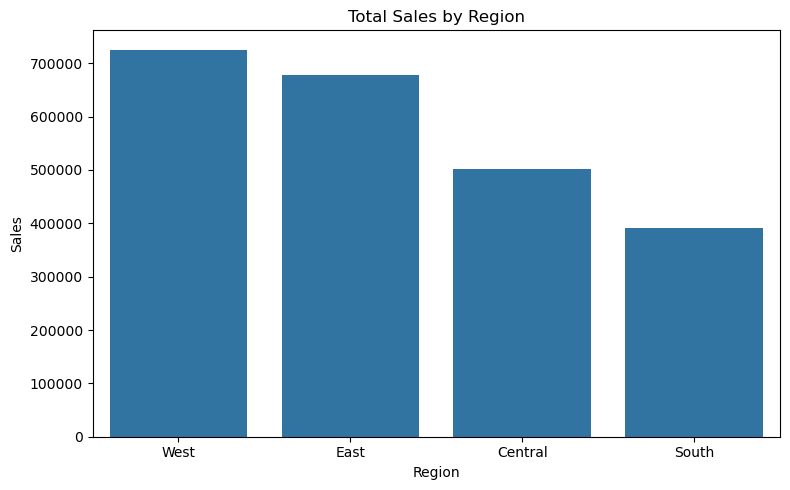

In [23]:
# Visualize sales by region

plt.figure(figsize =(8, 5))

sns.barplot(
    data = region_analysis,
    x = 'Region',
    y = 'Total_Sales'
)

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Segment-wise Sales & Profit Analysis

This analysis evaluates business performance across different customer segments.

The analysis includes:

- Total Sales by Segment
- Total Profit by Segment
- Profit Margin by Segment
- Comparison of segment-level performance

In [25]:
 # Analyze sales and profit by customer segment

segment_analysis = df.groupby('Segment').agg(
    Total_Sales = ('Sales', 'sum'),
    Total_Profit = ('Profit', 'sum')
).reset_index()

segment_analysis['Profit_Margin_%'] = (
    segment_analysis['Total_Profit']
    / segment_analysis['Total_Sales']
) * 100

segment_analysis = segment_analysis.sort_values(
    'Total_Sales',
    ascending = False
)

segment_analysis

,Segment,Total_Sales,Total_Profit,Profit_Margin_%
0,Consumer,1.161401e+06,134119.2092,11.548050
1,Corporate,7.061464e+05,91979.1340,13.025506
2,Home Office,4.296531e+05,60298.6785,14.034269


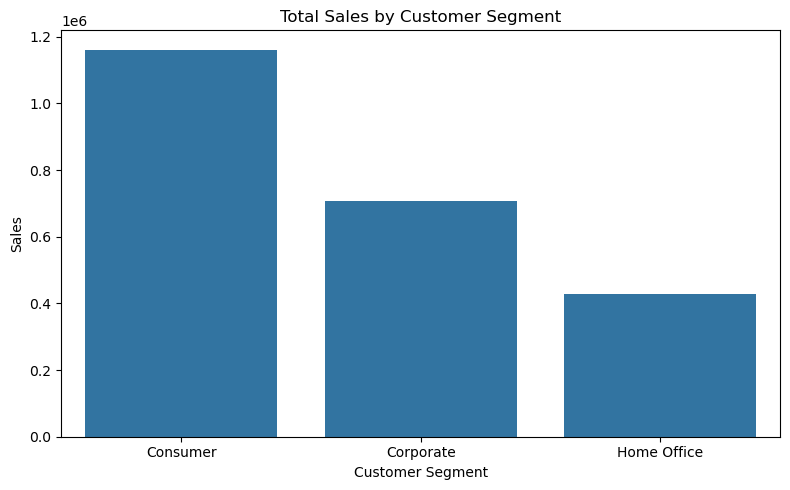

In [26]:
# Visualize sales by customer segment

plt.figure(figsize = (8, 5))

sns.barplot(
    data = segment_analysis,
    x = 'Segment',
    y = 'Total_Sales'
)

plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Sub-Category Analysis

This analysis evaluates sales and profitability across different product sub-categories.

The analysis includes:

- Total Sales by Sub-Category
- Total Profit by Sub-Category
- Profit Margin by Sub-Category
- Identification of high-performing and low-performing sub-categories

In [27]:
# Analyze sales and profit by sub-category

subcategory_analysis = df.groupby(
    ['Category', 'Sub-Category']
).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

subcategory_analysis['Profit_Margin_%'] = (
    subcategory_analysis['Total_Profit']
    / subcategory_analysis['Total_Sales']
) * 100

subcategory_analysis = subcategory_analysis.sort_values(
    'Total_Profit',
    ascending=False
)

subcategory_analysis

,Category,Sub-Category,Total_Sales,Total_Profit,Profit_Margin_%
14,Technology,Copiers,149528.0300,55617.8249,37.195585
16,Technology,Phones,330007.0540,44515.7306,13.489327
13,Technology,Accessories,167380.3180,41936.6357,25.054700
10,Office Supplies,Paper,78479.2060,34053.5693,43.391837
6,Office Supplies,Binders,203412.7330,30221.7633,14.857361
1,Furniture,Chairs,328449.1030,26590.1663,8.095673
11,Office Supplies,Storage,223843.6080,21278.8264,9.506113
4,Office Supplies,Appliances,107532.1610,18138.0054,16.867517
2,Furniture,Furnishings,91705.1640,13059.1436,14.240358
7,Office Supplies,Envelopes,16476.4020,6964.1767,42.267582


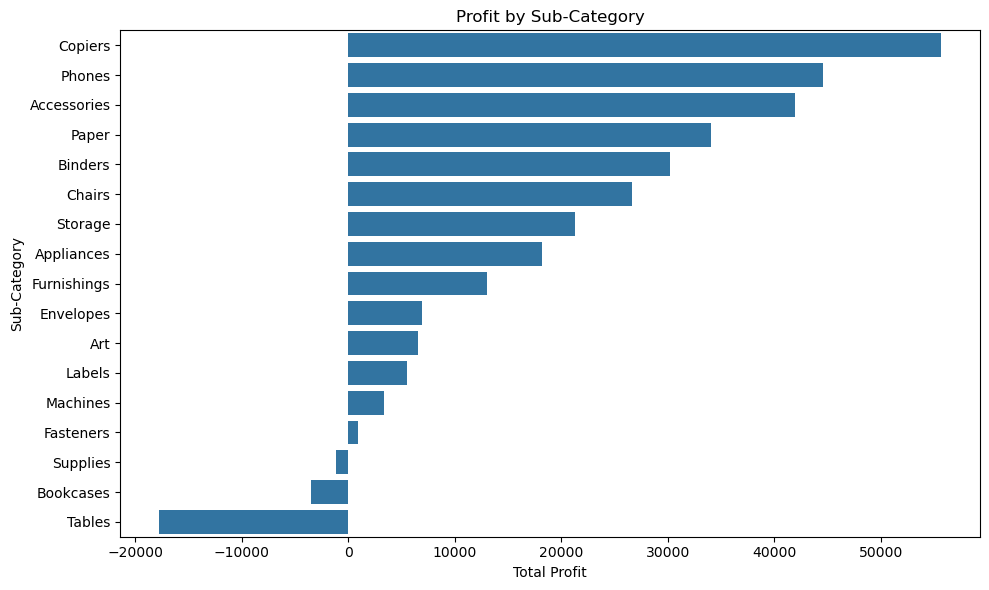

In [29]:
# Visualize profit by sub-category

plt.figure(figsize = (10, 6))

sns.barplot(
    data=subcategory_analysis,
    x = 'Total_Profit',
    y = 'Sub-Category'
)

plt.title('Profit by Sub-Category')
plt.xlabel('Total Profit')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

## 8. Time-Series Analysis

This section analyzes sales performance over time to identify business trends.

The analysis includes:

- Year-wise Sales and Profit
- Monthly Sales Trends
- Identification of growth and seasonal patterns

In [30]:
# Analyze yearly sales and profit

yearly_analysis = df.groupby(
    df['Order Date'].dt.year
).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

yearly_analysis.rename(
    columns={'Order Date': 'Year'},
    inplace=True
)

yearly_analysis

,Year,Total_Sales,Total_Profit
0,2014,484247.4981,49543.9741
1,2015,470532.5090,61618.6037
2,2016,609205.5980,81795.1743
3,2017,733215.2552,93439.2696


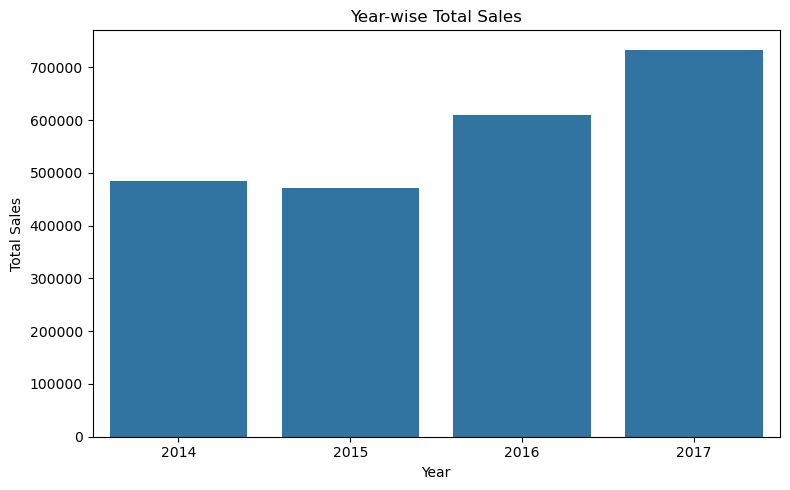

In [33]:
# Visualize yearly sales performance

plt.figure(figsize = (8, 5))

sns.barplot(
    data = yearly_analysis,
    x = 'Year',
    y = 'Total_Sales'
)

plt.title('Year-wise Total Sales')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

In [34]:
# Analyze monthly sales trend

monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum().reset_index()

monthly_sales['Order Date'] = monthly_sales['Order Date'].astype(str)

monthly_sales.head()

,Order Date,Sales
0,2014-01,14236.895
1,2014-02,4519.892
2,2014-03,55691.009
3,2014-04,28295.345
4,2014-05,23648.287


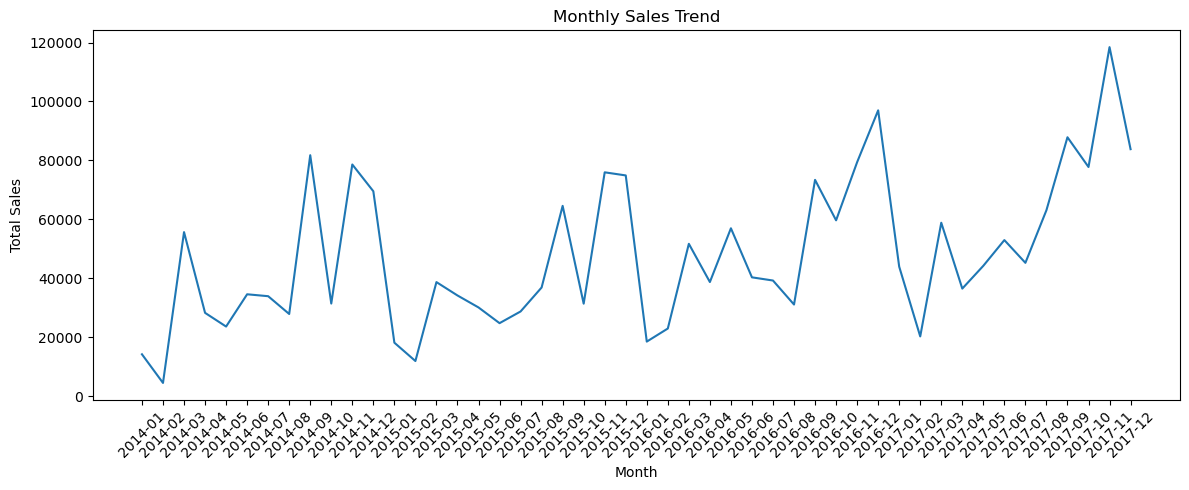

In [36]:
# Visualize monthly sales trend

plt.figure(figsize = (12, 5))

plt.plot(
    monthly_sales['Order Date'],
    monthly_sales['Sales']
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Profitability Analysis

This section focuses on understanding the profitability of different product categories.

The analysis includes:

- Total Sales
- Total Profit
- Profit Margin
- Comparison of profitability across categories

In [37]:
# Calculate profit margin by category

category_margin = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

category_margin['Profit_Margin_%'] = (
    category_margin['Total_Profit']
    / category_margin['Total_Sales']
) * 100

category_margin

,Category,Total_Sales,Total_Profit,Profit_Margin_%
0,Furniture,741999.7953,18451.2728,2.486695
1,Office Supplies,719047.0320,122490.8008,17.035158
2,Technology,836154.0330,145454.9481,17.395712


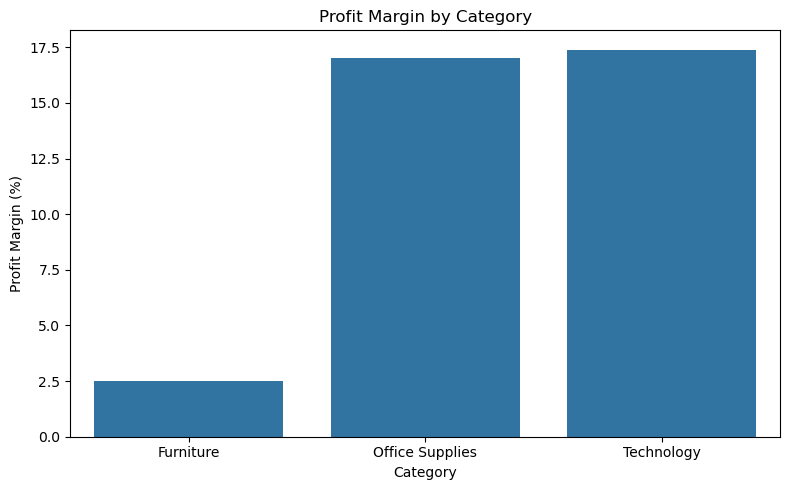

In [38]:
# Visualize profit margin by category

plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_margin,
    x='Category',
    y='Profit_Margin_%'
)

plt.title('Profit Margin by Category')
plt.xlabel('Category')
plt.ylabel('Profit Margin (%)')
plt.tight_layout()
plt.show()

## 10. Discount Analysis

This section analyzes the relationship between discounts and profitability.

The analysis includes:

- Discount levels
- Total Sales
- Total Profit
- Profit Margin at different discount levels
- Impact of discounting on profitability

In [39]:
# Analyze the impact of discount on profitability

discount_analysis = df.groupby('Discount').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

discount_analysis['Profit_Margin_%'] = (
    discount_analysis['Total_Profit']
    / discount_analysis['Total_Sales']
) * 100

discount_analysis

,Discount,Total_Sales,Total_Profit,Profit_Margin_%
0,0.00,1.087908e+06,320987.6032,29.505019
1,0.10,5.436935e+04,9029.1770,16.607108
2,0.15,2.755852e+04,1418.9915,5.149012
3,0.20,7.645944e+05,90337.3060,11.815063
4,0.30,1.032267e+05,-10369.2774,-10.045155
5,0.32,1.449346e+04,-2391.1377,-16.498047
6,0.40,1.164178e+05,-23057.0504,-19.805437
7,0.45,5.484974e+03,-2493.1111,-45.453472
8,0.50,5.891854e+04,-20506.4281,-34.804712
9,0.60,6.644700e+03,-5944.6552,-89.464614


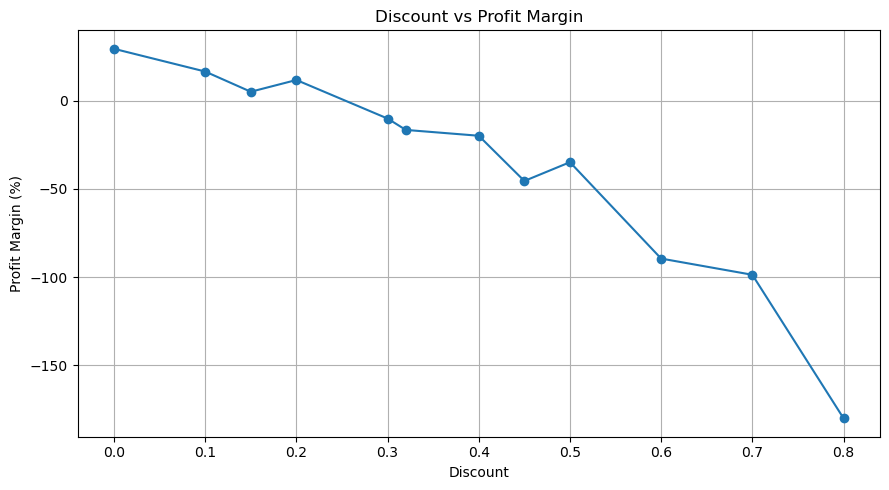

In [41]:
# Visualize the relationship between discount and profit margin

plt.figure(figsize = (9, 5))

plt.plot(
    discount_analysis['Discount'],
    discount_analysis['Profit_Margin_%'],
    marker = 'o'
)

plt.title('Discount vs Profit Margin')
plt.xlabel('Discount')
plt.ylabel('Profit Margin (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

## 11. Customer Analysis

This section analyzes customer-level sales and profitability.

The analysis includes:

- Total Orders by Customer
- Total Sales by Customer
- Total Profit by Customer
- Average Order Value
- Identification of high-value customers

In [42]:
# Analyze customer performance

customer_analysis = df.groupby(
    ['Customer ID', 'Customer Name']
).agg(
    Total_Orders=('Order ID', 'nunique'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

customer_analysis['Average_Order_Value'] = (
    customer_analysis['Total_Sales']
    / customer_analysis['Total_Orders']
)

customer_analysis = customer_analysis.sort_values(
    'Total_Profit',
    ascending=False
)

customer_analysis.head(10)

,Customer ID,Customer Name,Total_Orders,Total_Sales,Total_Profit,Average_Order_Value
741,TC-20980,Tamara Chand,5,19052.218,8981.3239,3810.443600
621,RB-19360,Raymond Buch,6,15117.339,6976.0959,2519.556500
669,SC-20095,Sanjit Chand,9,14142.334,5757.4119,1571.370444
327,HL-15040,Hunter Lopez,6,12873.298,5622.4292,2145.549667
6,AB-10105,Adrian Barton,10,14473.571,5444.8055,1447.357100
730,TA-21385,Tom Ashbrook,4,14595.620,4703.7883,3648.905000
160,CM-12385,Christopher Martinez,4,8954.020,3899.8904,2238.505000
424,KD-16495,Keith Dawkins,12,8181.256,3038.6254,681.771333
48,AR-10540,Andy Reiter,6,6608.448,2884.6208,1101.408000
234,DR-12940,Daniel Raglin,8,8350.868,2869.0760,1043.858500


In [43]:
# Identify the top 10 most profitable customers

top_customers = customer_analysis.head(10)

top_customers

,Customer ID,Customer Name,Total_Orders,Total_Sales,Total_Profit,Average_Order_Value
741,TC-20980,Tamara Chand,5,19052.218,8981.3239,3810.443600
621,RB-19360,Raymond Buch,6,15117.339,6976.0959,2519.556500
669,SC-20095,Sanjit Chand,9,14142.334,5757.4119,1571.370444
327,HL-15040,Hunter Lopez,6,12873.298,5622.4292,2145.549667
6,AB-10105,Adrian Barton,10,14473.571,5444.8055,1447.357100
730,TA-21385,Tom Ashbrook,4,14595.620,4703.7883,3648.905000
160,CM-12385,Christopher Martinez,4,8954.020,3899.8904,2238.505000
424,KD-16495,Keith Dawkins,12,8181.256,3038.6254,681.771333
48,AR-10540,Andy Reiter,6,6608.448,2884.6208,1101.408000
234,DR-12940,Daniel Raglin,8,8350.868,2869.0760,1043.858500


## 12. Product Analysis

This section evaluates product-level sales and profitability to identify the strongest and weakest performing products.

The analysis includes:

- Top 10 most profitable products
- Top 10 loss-making products
- Comparison of product-level profitability
- Identification of products requiring business attention

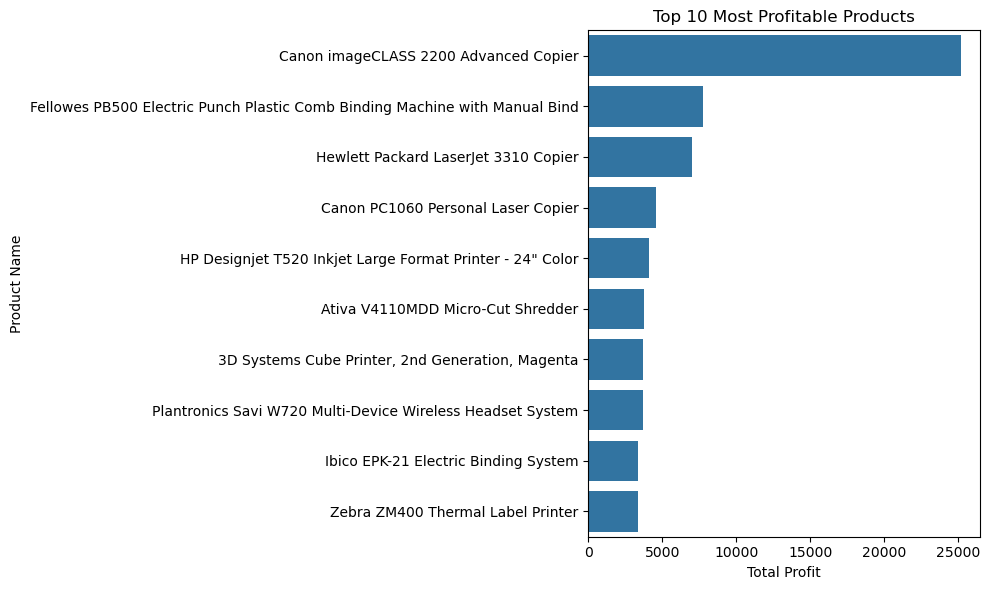

In [45]:
# Visualize the top 10 most profitable products

top_profit_products = product_analysis.sort_values(
    'Total_Profit',
    ascending = False
).head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data = top_profit_products,
    x = 'Total_Profit',
    y = 'Product Name'
)

plt.title('Top 10 Most Profitable Products')
plt.xlabel('Total Profit')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

In [44]:
# Identify the top 10 loss-making products

product_analysis = df.groupby(
    ['Product ID', 'Product Name']
).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

product_analysis = product_analysis.sort_values(
    'Total_Profit',
    ascending=True
)

product_analysis.head(10)

,Product ID,Product Name,Total_Sales,Total_Profit
1645,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704
1650,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730
1696,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904
326,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.640,-2876.1156
344,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,9544.725,-1934.3976
858,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662
1669,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784
1465,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,16656.200,-1299.1836
346,FUR-TA-10001950,Balt Solid Wood Round Tables,6518.754,-1201.0581
375,FUR-TA-10004289,BoxOffice By Design Rectangular and Half-Moon ...,1706.250,-1148.4375


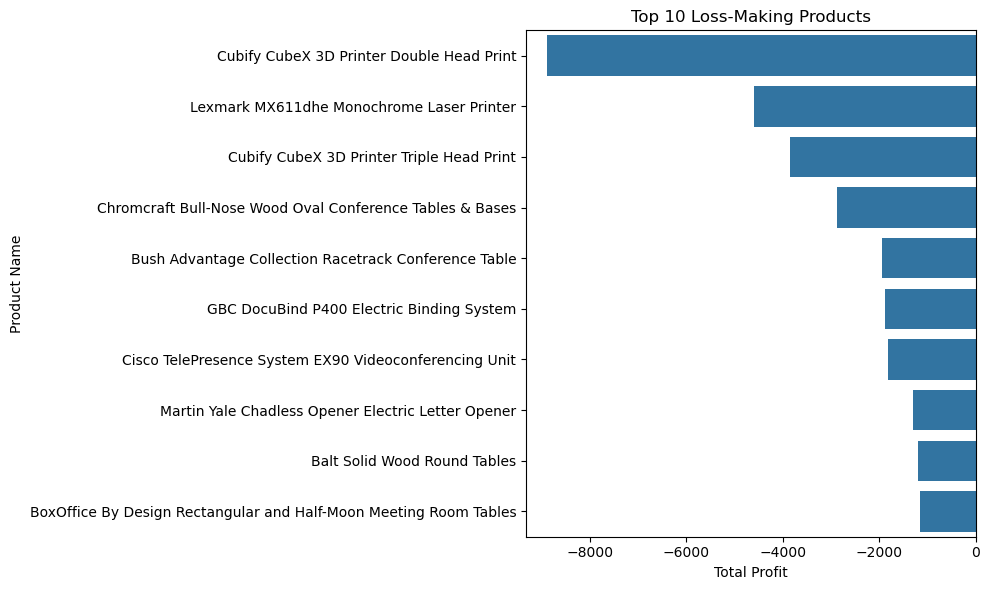

In [47]:
# Visualize the top 10 loss-making products

top_loss_products = product_analysis.sort_values(
    'Total_Profit',
    ascending=True
).head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_loss_products,
    x='Total_Profit',
    y='Product Name'
)

plt.title('Top 10 Loss-Making Products')
plt.xlabel('Total Profit')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

## 13. Quantity & Sales Analysis

This section analyzes the sales volume across different product categories.

The analysis includes:

- Total Quantity Sold by Category
- Total Sales by Category
- Total Profit by Category
- Comparison of sales volume and business performance

In [48]:
# Analyze quantity sold by category

quantity_analysis = df.groupby('Category').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

quantity_analysis

,Category,Total_Quantity,Total_Sales,Total_Profit
0,Furniture,8028,741999.7953,18451.2728
1,Office Supplies,22906,719047.0320,122490.8008
2,Technology,6939,836154.0330,145454.9481


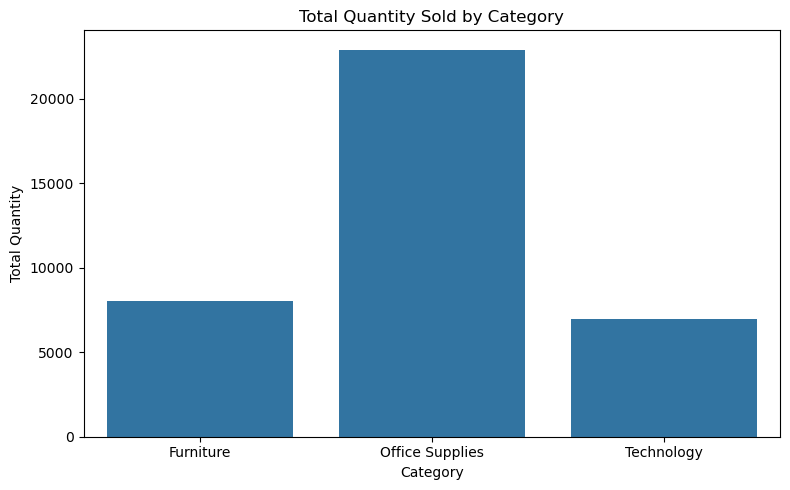

In [49]:
# Visualize quantity sold by category

plt.figure(figsize=(8, 5))

sns.barplot(
    data=quantity_analysis,
    x='Category',
    y='Total_Quantity'
)

plt.title('Total Quantity Sold by Category')
plt.xlabel('Category')
plt.ylabel('Total Quantity')
plt.tight_layout()
plt.show()

## 14. Shipping Analysis

This section evaluates sales, orders, and profitability across different shipping modes.

The analysis includes:

- Total Orders by Shipping Mode
- Total Sales by Shipping Mode
- Total Profit by Shipping Mode
- Profit Margin by Shipping Mode

In [50]:
# Analyze sales and profit by shipping mode

ship_mode_analysis = df.groupby('Ship Mode').agg(
    Total_Orders=('Order ID', 'nunique'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

ship_mode_analysis['Profit_Margin_%'] = (
    ship_mode_analysis['Total_Profit']
    / ship_mode_analysis['Total_Sales']
) * 100

ship_mode_analysis

,Ship Mode,Total_Orders,Total_Sales,Total_Profit,Profit_Margin_%
0,First Class,787,3.514284e+05,48969.8399,13.934513
1,Same Day,264,1.283631e+05,15891.7589,12.380315
2,Second Class,964,4.591936e+05,57446.6354,12.510331
3,Standard Class,2994,1.358216e+06,164088.7875,12.081202


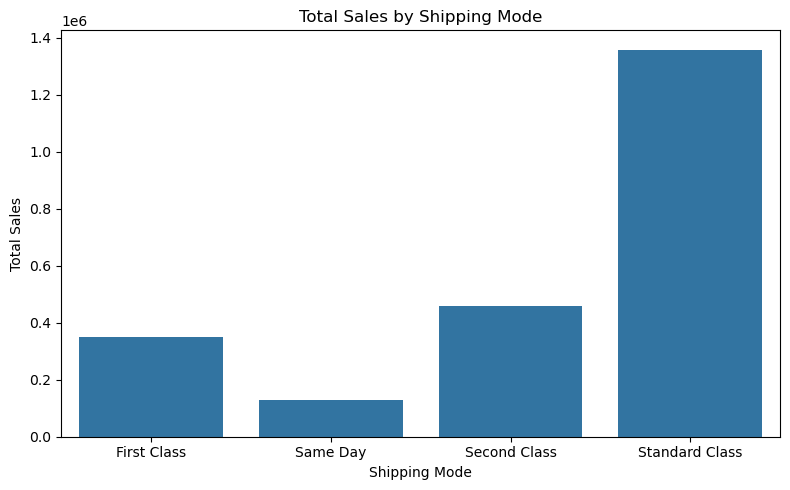

In [51]:
# Visualize sales by shipping mode

plt.figure(figsize = (8, 5))

sns.barplot(
    data=ship_mode_analysis,
    x = 'Ship Mode',
    y = 'Total_Sales'
)

plt.title('Total Sales by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

## 15. Regional Comparison

This section compares sales and profit performance across different regions.

The analysis includes:

- Total Sales by Region
- Total Profit by Region
- Comparison of regional performance
- Identification of differences between sales and profitability

In [64]:
# Compare sales and profit by region

region_comparison = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

region_comparison

,Region,Total_Sales,Total_Profit
0,Central,501239.8908,39706.3625
1,East,678781.2400,91522.7800
2,South,391721.9050,46749.4303
3,West,725457.8245,108418.4489


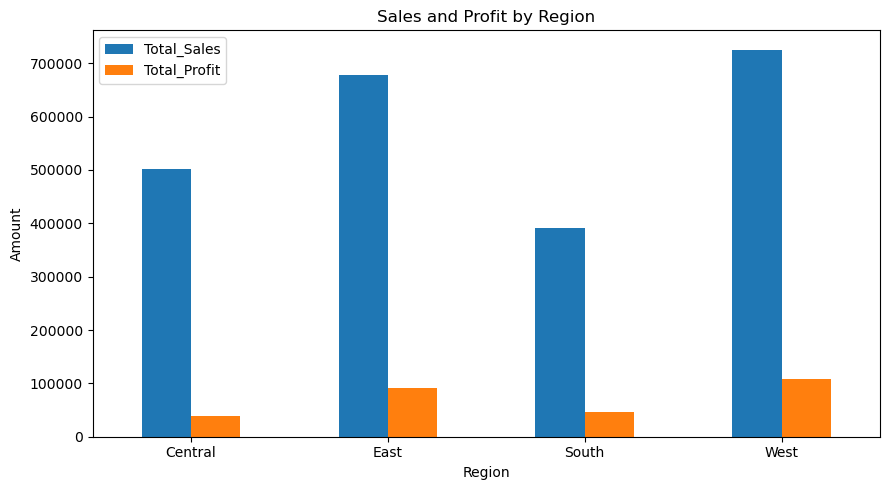

In [53]:
# Visualize sales and profit by region

region_comparison.plot(
    x='Region',
    y=['Total_Sales', 'Total_Profit'],
    kind='bar',
    figsize=(9, 5)
)

plt.title('Sales and Profit by Region')
plt.xlabel('Region')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 16. Customer Retention Analysis

This section analyzes customer purchasing behavior to understand customer retention patterns.

The analysis includes:

- Repeat Customers
- One-Time Customers
- Comparison of customer types
- Understanding customer retention patterns

In [54]:
# Classify customers as repeat or one-time customers

customer_orders = df.groupby('Customer ID')['Order ID'].nunique()

customer_type = pd.DataFrame({
    'Customer ID': customer_orders.index,
    'Total Orders': customer_orders.values
})

customer_type['Customer Type'] = np.where(
    customer_type['Total Orders'] > 1,
    'Repeat Customer',
    'One-Time Customer'
)

customer_type['Customer Type'].value_counts()

Customer Type
Repeat Customer      781
One-Time Customer     12
Name: count, dtype: int64

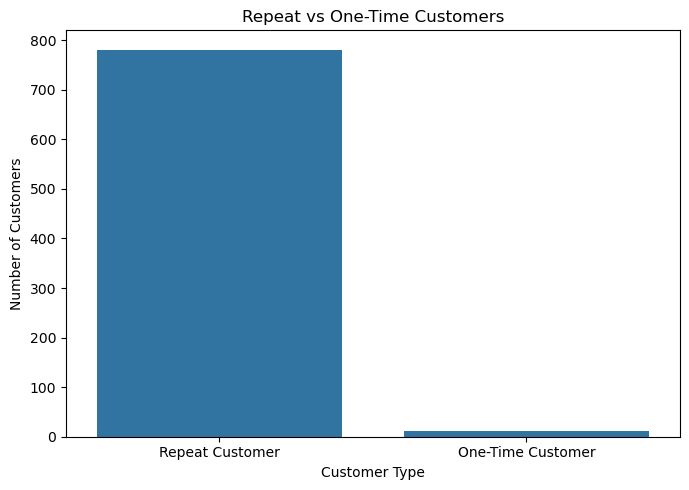

In [55]:
# Visualize repeat vs one-time customers

customer_type_counts = customer_type['Customer Type'].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=customer_type_counts.index,
    y=customer_type_counts.values
)

plt.title('Repeat vs One-Time Customers')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 17. Sales vs Profit Relationship Analysis

This section examines the relationship between sales and profit at the transaction level.

The analysis uses a scatter plot to understand:

- Relationship between Sales and Profit
- Distribution of profitable and loss-making transactions
- Whether higher sales are associated with higher profit
- Identification of unusual or low-profit transactions

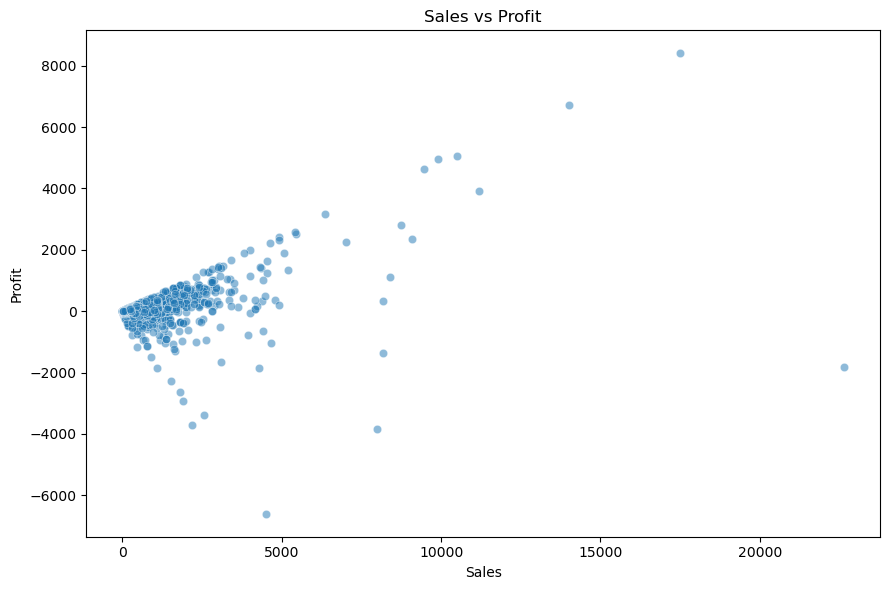

In [57]:
# Analyze the relationship between sales and profit

plt.figure(figsize = (9, 6))

sns.scatterplot(
    data = df,
    x = 'Sales',
    y = 'Profit',
    alpha=0.5
)

plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

## 18. Correlation Analysis

This section examines the relationships between key numerical business variables.

The analysis includes:

- Sales
- Quantity
- Discount
- Profit
- Correlation between business variables
- Visualization using a correlation heatmap

In [58]:
# Calculate correlation between key numerical variables

correlation_matrix = df[
    ['Sales', 'Quantity', 'Discount', 'Profit']
].corr()

correlation_matrix

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


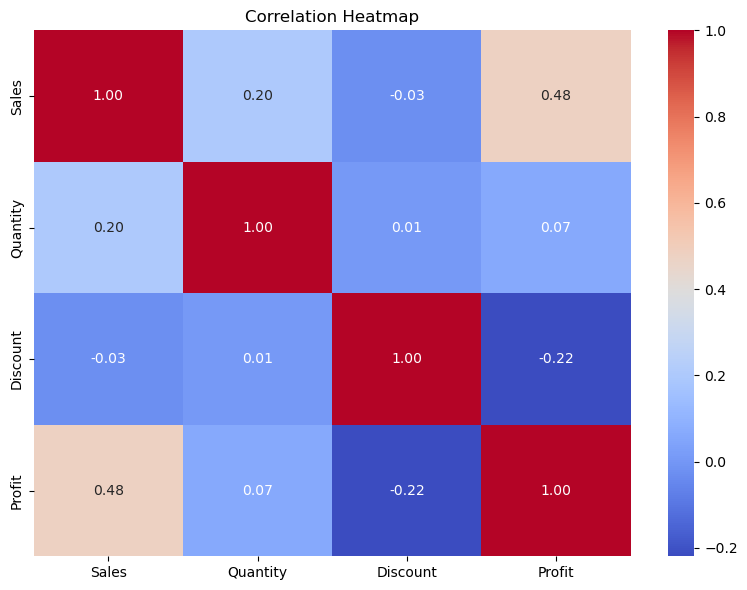

In [59]:
# Visualize correlations between key numerical variables

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 19. State-wise Sales & Profit Analysis

This section analyzes business performance across different states.

The analysis includes:

- Total Sales by State
- Total Profit by State
- Top 10 States by Sales
- Comparison of state-level performance
- Identification of important geographic markets

In [60]:
# Identify the top 10 states by sales

state_analysis = df.groupby('State').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

top_states = state_analysis.sort_values(
    'Total_Sales',
    ascending=False
).head(10)

top_states

,State,Total_Sales,Total_Profit
3,California,457687.6315,76381.3871
30,New York,310876.2710,74038.5486
41,Texas,170188.0458,-25729.3563
45,Washington,138641.2700,33402.6517
36,Pennsylvania,116511.9140,-15559.9603
8,Florida,89473.7080,-3399.3017
11,Illinois,80166.1010,-12607.8870
33,Ohio,78258.1360,-16971.3766
20,Michigan,76269.6140,24463.1876
44,Virginia,70636.7200,18597.9504


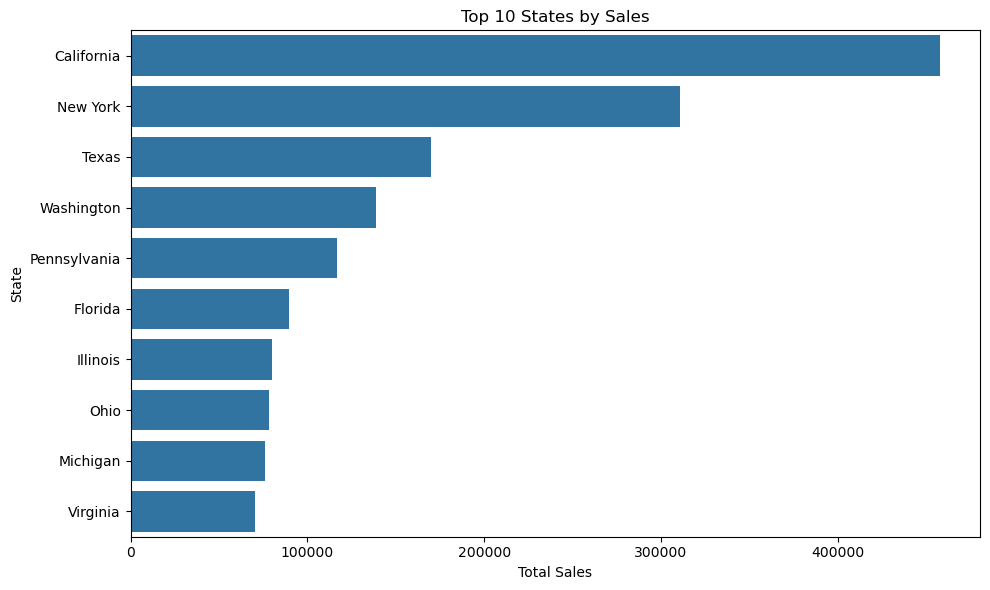

In [61]:
# Visualize the top 10 states by sales

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_states,
    x='Total_Sales',
    y='State'
)

plt.title('Top 10 States by Sales')
plt.xlabel('Total Sales')
plt.ylabel('State')
plt.tight_layout()
plt.show()

## 20. Final Business KPIs

This section presents the final key performance indicators derived from the retail sales dataset.

The KPIs include:

- Total Sales
- Total Profit
- Overall Profit Margin
- Total Orders
- Total Customers
- Average Order Value

These KPIs provide a concise overview of the overall business performance.

In [62]:
# Final KPI summary

profit_margin = (total_profit / total_sales) * 100
avg_order_value = total_sales / total_orders

print("===== FINAL BUSINESS KPIs =====")
print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Profit Margin:", round(profit_margin, 2), "%")
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(avg_order_value, 2))

===== FINAL BUSINESS KPIs =====
Total Sales: 2297200.86
Total Profit: 286397.02
Profit Margin: 12.47 %
Total Orders: 5009
Total Customers: 793
Average Order Value: 458.61


## 21. Final Business Insights & Recommendations

### Key Business Insights

- Technology is one of the strongest-performing product categories.
- Furniture generates significant sales but has comparatively lower profitability.
- Tables show negative profitability and require further performance review.
- Regional performance varies across sales and profit.
- Higher discount levels are associated with lower profit margins.
- Some products generate high sales but relatively low profit.

### Business Recommendations

- Review high-discount transactions to improve profit margins.
- Reassess pricing and discount strategies for low-profit products.
- Focus on high-margin products and profitable customer segments.
- Analyze regional performance to identify opportunities for profitable growth.
- Monitor product-level profitability regularly to support better business decisions.

### Conclusion

The analysis demonstrates how Excel, SQL, Python, and Power BI can be combined to transform raw retail data into meaningful business insights and actionable recommendations.